In [2]:
import os, json, random, time, warnings, gc
import numpy as np
from pathlib import Path
from PIL import Image, ImageDraw
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import Dataset, DataLoader
from transformers import CLIPSegProcessor, CLIPSegForImageSegmentation

import albumentations as A
from albumentations.pytorch import ToTensorV2

warnings.filterwarnings("ignore")

In [6]:
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): 
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

BASE_DIR   = Path("./working").resolve()
CKPT_PATH  = BASE_DIR / "best_model.pt"
PRED_DIR   = BASE_DIR / "predictions"
PRED_DIR.mkdir(parents=True, exist_ok=True)

TAPING_DIR = Path("/kaggle/input/datasets/amansinghbudhala/drywall-join-detect-v2i-coco")
CRACKS_DIR = Path("/kaggle/input/datasets/amansinghbudhala/cracks-coco")

PROMPTS_TAPING = ["segment taping area", "segment joint/tape", "segment drywall seam"]
PROMPTS_CRACK  = ["segment crack", "segment wall crack"]
MODEL_NAME     = "CIDAS/clipseg-rd64-refined"

CLIPSEG_SIZE  = 352
BATCH_SIZE    = 16    
EPOCHS        = 25
WARMUP_EPOCHS = 3
LR_DECODER    = 3e-4  
LR_ENCODER    = 3e-6  
USE_FP16      = True  
FOCAL_W       = 0.4   
TVERSKY_W     = 0.6   


Device: cuda


In [7]:
def create_mask_from_coco(ann, height, width):
    mask = Image.new("L", (width, height), 0)
    draw = ImageDraw.Draw(mask)
    has_poly = "segmentation" in ann and isinstance(ann["segmentation"], list) and len(ann["segmentation"]) > 0
    if has_poly:
        for seg in ann["segmentation"]:
            if len(seg) >= 6:
                poly = [(seg[i], seg[i + 1]) for i in range(0, len(seg), 2)]
                draw.polygon(poly, fill=255)
    elif "bbox" in ann:
        x, y, w, h = ann["bbox"]
        draw.rectangle([x, y, x + w, y + h], fill=255)
    return np.array(mask, dtype=np.uint8)

def load_split(dataset_dir, task_type, split):
    ann_file = Path(dataset_dir) / split / "_annotations.coco.json"
    if not ann_file.exists(): return []
    with open(ann_file) as f: coco = json.load(f)
    id2img  = {img["id"]: img for img in coco["images"]}
    img2ann = {}
    for ann in coco["annotations"]: img2ann.setdefault(ann["image_id"], []).append(ann)

    items = []
    for img_id, img_info in id2img.items():
        img_path = Path(dataset_dir) / split / img_info["file_name"]
        if not img_path.exists(): continue
        h, w = img_info["height"], img_info["width"]
        combined = np.zeros((h, w), dtype=np.uint8)
        for ann in img2ann.get(img_id, []):
            m = create_mask_from_coco(ann, h, w)
            combined = np.maximum(combined, m)
        items.append({
            "image_path": str(img_path), "orig_mask": combined,
            "task_type": task_type, "image_id": Path(img_info["file_name"]).stem
        })
    return items

def manual_split(items, val_ratio=0.15, test_ratio=0.15):
    if not items: return [], [], []
    data = items.copy()
    random.Random(SEED).shuffle(data)
    n = len(data)
    n_test = max(1, int(n * test_ratio))
    n_val  = max(1, int(n * val_ratio))
    return data[n_test + n_val:], data[n_test : n_test + n_val], data[:n_test]

taping_train_raw = load_split(TAPING_DIR, "taping", "train")
taping_valid_raw = load_split(TAPING_DIR, "taping", "valid")
mid = max(1, len(taping_valid_raw) // 2)
taping_val, taping_test = taping_valid_raw[:mid], taping_valid_raw[mid:]

cracks_all = load_split(CRACKS_DIR, "crack", "train")
cracks_train_raw, cracks_val, cracks_test = manual_split(cracks_all)

if 0 < len(cracks_train_raw) < len(taping_train_raw):
    multiplier = len(taping_train_raw) // len(cracks_train_raw)
    remainder = len(taping_train_raw) % len(cracks_train_raw)
    cracks_train = (cracks_train_raw * multiplier) + cracks_train_raw[:remainder]
else:
    cracks_train = cracks_train_raw

train_items = taping_train_raw + cracks_train
val_items   = taping_val + cracks_val
test_items  = taping_test + cracks_test

CLIP_MEAN, CLIP_STD = (0.48145466, 0.4578275, 0.40821073), (0.26862954, 0.26130258, 0.27577711)

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.2), A.RandomBrightnessContrast(p=0.2),
    A.Normalize(mean=CLIP_MEAN, std=CLIP_STD), ToTensorV2()
])
val_transform = A.Compose([A.Normalize(mean=CLIP_MEAN, std=CLIP_STD), ToTensorV2()])

processor = CLIPSegProcessor.from_pretrained(MODEL_NAME)

class DrywallDatasetDynamicRAM(Dataset):
    def __init__(self, items, processor, transforms, is_train=False, desc="Loading"):
        self.items = items
        self.transforms = transforms
        self.is_train = is_train
        
        self.images, self.masks = [], []
        self.enc_taping = [processor(text=[p], padding="max_length", max_length=77, truncation=True, return_tensors="pt") for p in PROMPTS_TAPING]
        self.enc_crack  = [processor(text=[p], padding="max_length", max_length=77, truncation=True, return_tensors="pt") for p in PROMPTS_CRACK]

        for item in tqdm(items, desc=desc):
            img = Image.open(item["image_path"]).convert("RGB")
            self.images.append(np.array(img.resize((CLIPSEG_SIZE, CLIPSEG_SIZE), Image.BILINEAR)))
            mask = Image.fromarray(item["orig_mask"]).resize((CLIPSEG_SIZE, CLIPSEG_SIZE), Image.NEAREST)
            self.masks.append(np.array(mask, dtype=np.uint8))

    def __len__(self): return len(self.items)

    def __getitem__(self, idx):
        item = self.items[idx]
        augmented = self.transforms(image=self.images[idx], mask=self.masks[idx])
        image_tensor = augmented['image']
        mask_tensor = augmented['mask'].float() / 255.0

        if item["task_type"] == "taping":
            p_idx = random.randint(0, len(PROMPTS_TAPING)-1) if self.is_train else 0
            txt_enc, prompt_str = self.enc_taping[p_idx], PROMPTS_TAPING[p_idx]
        else:
            p_idx = random.randint(0, len(PROMPTS_CRACK)-1) if self.is_train else 0
            txt_enc, prompt_str = self.enc_crack[p_idx], PROMPTS_CRACK[p_idx]

        enc_out = {
            "pixel_values": image_tensor,
            "input_ids": txt_enc["input_ids"].squeeze(0),
            "attention_mask": txt_enc["attention_mask"].squeeze(0)
        }
        return enc_out, mask_tensor, prompt_str, item["task_type"]

def collate_fn(batch):
    encs, masks, prompts, task_types = zip(*batch)
    batched_enc = {k: torch.stack([e[k] for e in encs]) for k in encs[0]}
    return batched_enc, torch.stack(masks), list(prompts), list(task_types)

print("\nCaching datasets in RAM...")
train_ds = DrywallDatasetDynamicRAM(train_items, processor, train_transform, True, "Train Data")
val_ds   = DrywallDatasetDynamicRAM(val_items, processor, val_transform, False, "Val Data")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, collate_fn=collate_fn, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, collate_fn=collate_fn, pin_memory=True)


preprocessor_config.json:   0%|          | 0.00/380 [00:00<?, ?B/s]

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/974 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]


Caching datasets in RAM...


Train Data:   0%|          | 0/4579 [00:00<?, ?it/s]

Val Data:   0%|          | 0/906 [00:00<?, ?it/s]

In [8]:
model = CLIPSegForImageSegmentation.from_pretrained(MODEL_NAME)
model.to(DEVICE)

for p in model.clip.text_model.parameters(): p.requires_grad = False

optimizer = torch.optim.AdamW([
    {'params': list(model.decoder.parameters()), 'lr': LR_DECODER, 'initial_lr': LR_DECODER},
    {'params': [p for p in model.clip.vision_model.parameters() if p.requires_grad],  'lr': LR_ENCODER, 'initial_lr': LR_ENCODER},
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-7)
scaler    = GradScaler(enabled=USE_FP16)

def focal_loss(logits, targets, alpha=0.75, gamma=2.0):
    bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
    pt = torch.exp(-bce)
    f_loss = (targets * alpha + (1 - targets) * (1 - alpha)) * (1 - pt)**gamma * bce
    return f_loss.mean()

def tversky_loss(logits, targets, alpha=0.3, beta=0.7, smooth=1.0):
    probs = torch.sigmoid(logits)
    TP = (probs * targets).sum(dim=(-2, -1))
    FP = ((1 - targets) * probs).sum(dim=(-2, -1))
    FN = (targets * (1 - probs)).sum(dim=(-2, -1))
    return 1.0 - ((TP + smooth) / (TP + alpha * FP + beta * FN + smooth)).mean()

def combined_loss(logits, targets):
    return FOCAL_W * focal_loss(logits, targets) + TVERSKY_W * tversky_loss(logits, targets)

model.safetensors:   0%|          | 0.00/603M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/462 [00:00<?, ?it/s]

CLIPSegForImageSegmentation LOAD REPORT from: CIDAS/clipseg-rd64-refined
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
clip.vision_model.embeddings.position_ids | UNEXPECTED |  | 
clip.text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [9]:
@torch.no_grad()
def evaluate_with_threshold_search(model, loader):
    model.eval()
    all_probs, all_masks, all_tasks = [], [], []

    for enc, masks, _, task_types in loader:
        enc_gpu = {k: v.to(DEVICE) for k, v in enc.items()}
        with autocast(enabled=USE_FP16):
            logits = model(**enc_gpu).logits
            if logits.dim() == 4: logits = logits.squeeze(1)
            probs = torch.sigmoid(logits).cpu()
        all_probs.append(probs)
        all_masks.append(masks)
        all_tasks.extend(task_types)

    probs_tensor = torch.cat(all_probs)
    masks_tensor = torch.cat(all_masks).bool()
    tasks_arr = np.array(all_tasks)

    best_score, best_thr = -1.0, 0.5
    best_metrics = {}

    for t in np.arange(0.15, 0.85, 0.05):
        preds = (probs_tensor > t)
        t_dice, t_iou, c_dice, c_iou = 0.0, 0.0, 0.0, 0.0
        
        tape_idx = np.where(tasks_arr == "taping")[0]
        if len(tape_idx) > 0:
            p_tape, m_tape = preds[tape_idx], masks_tensor[tape_idx]
            inter = (p_tape & m_tape).float().sum(dim=(1,2))
            union = (p_tape | m_tape).float().sum(dim=(1,2))
            t_iou = ((inter + 1e-6) / (union + 1e-6)).mean().item()
            t_dice = ((2 * inter + 1e-6) / (p_tape.float().sum(dim=(1,2)) + m_tape.float().sum(dim=(1,2)) + 1e-6)).mean().item()

        crack_idx = np.where(tasks_arr == "crack")[0]
        if len(crack_idx) > 0:
            p_crack, m_crack = preds[crack_idx], masks_tensor[crack_idx]
            inter = (p_crack & m_crack).float().sum(dim=(1,2))
            union = (p_crack | m_crack).float().sum(dim=(1,2))
            c_iou = ((inter + 1e-6) / (union + 1e-6)).mean().item()
            c_dice = ((2 * inter + 1e-6) / (p_crack.float().sum(dim=(1,2)) + m_crack.float().sum(dim=(1,2)) + 1e-6)).mean().item()

        mean_dice = (t_dice + c_dice) / 2
        mean_iou = (t_iou + c_iou) / 2
        combined_score = (mean_dice + mean_iou) / 2
        
        if combined_score > best_score:
            best_score = combined_score
            best_thr = float(t)
            best_metrics = {
                "tape_dice": t_dice, "tape_iou": t_iou,
                "crack_dice": c_dice, "crack_iou": c_iou, 
                "mean_dice": mean_dice, "mean_iou": mean_iou
            }

    return best_metrics, best_thr


In [10]:
best_val_score = -1.0
best_model_thr = 0.5
history = {'train_loss': [], 'val_dice': [], 'val_iou': []}

print("\nStarting Optimized Mixed-Precision Training...")
for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    
    if epoch <= WARMUP_EPOCHS:
        warmup_factor = epoch / WARMUP_EPOCHS
        for g in optimizer.param_groups:
            if 'initial_lr' in g: g['lr'] = g['initial_lr'] * warmup_factor

    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}", leave=False)
    for enc, masks, _, _ in pbar:
        enc_gpu = {k: v.to(DEVICE) for k, v in enc.items()}
        masks_gpu = masks.to(DEVICE)

        optimizer.zero_grad()
        with autocast(enabled=USE_FP16):
            logits = model(**enc_gpu).logits
            if logits.dim() == 4: logits = logits.squeeze(1)
            loss = combined_loss(logits, masks_gpu)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        
        epoch_loss += loss.item()
        pbar.set_postfix(loss=loss.item())

    if epoch > WARMUP_EPOCHS: scheduler.step()

    avg_loss = epoch_loss / len(train_loader)
    metrics, opt_thr = evaluate_with_threshold_search(model, val_loader)
    
    history['train_loss'].append(avg_loss)
    history['val_dice'].append(metrics['mean_dice'])
    history['val_iou'].append(metrics['mean_iou'])
    
    print(f"\nEpoch {epoch:02d} | Loss: {avg_loss:.4f} (Thr: {opt_thr:.2f})")
    print(f"  -> Tape   | mIoU: {metrics['tape_iou']:.4f}  |  Dice: {metrics['tape_dice']:.4f}")
    print(f"  -> Crack  | mIoU: {metrics['crack_iou']:.4f}  |  Dice: {metrics['crack_dice']:.4f}")
    print(f"  -> OVERALL| mIoU: {metrics['mean_iou']:.4f}  |  Dice: {metrics['mean_dice']:.4f}")

    combined_score = (metrics["mean_dice"] + metrics["mean_iou"]) / 2
    if combined_score > best_val_score:
        best_val_score = combined_score
        best_model_thr = opt_thr
        torch.save(model.state_dict(), CKPT_PATH)
        print(f"  [!] Best Model Saved! (Score: {best_val_score:.4f})")
        
    gc.collect(); torch.cuda.empty_cache()

print(f"\nTraining Complete. Best Overall Combined Score: {best_val_score:.4f}")



Starting Optimized Mixed-Precision Training...


Epoch 1/25:   0%|          | 0/287 [00:00<?, ?it/s]


Epoch 01 | Loss: 0.3242 (Thr: 0.65)
  -> Tape   | mIoU: 0.3345  |  Dice: 0.4823
  -> Crack  | mIoU: 0.4075  |  Dice: 0.5511
  -> OVERALL| mIoU: 0.3710  |  Dice: 0.5167
  [!] Best Model Saved! (Score: 0.4438)


Epoch 2/25:   0%|          | 0/287 [00:00<?, ?it/s]


Epoch 02 | Loss: 0.2717 (Thr: 0.80)
  -> Tape   | mIoU: 0.4973  |  Dice: 0.6523
  -> Crack  | mIoU: 0.4339  |  Dice: 0.5788
  -> OVERALL| mIoU: 0.4656  |  Dice: 0.6155
  [!] Best Model Saved! (Score: 0.5406)


...


Epoch 23 | Loss: 0.1556 (Thr: 0.80)
  -> Tape   | mIoU: 0.6689  |  Dice: 0.7942
  -> Crack  | mIoU: 0.5576  |  Dice: 0.6985
  -> OVERALL| mIoU: 0.6132  |  Dice: 0.7463


Epoch 24/25:   0%|          | 0/287 [00:00<?, ?it/s]


Epoch 24 | Loss: 0.1549 (Thr: 0.80)
  -> Tape   | mIoU: 0.6709  |  Dice: 0.7955
  -> Crack  | mIoU: 0.5584  |  Dice: 0.6993
  -> OVERALL| mIoU: 0.6146  |  Dice: 0.7474
  [!] Best Model Saved! (Score: 0.6810)


Epoch 25/25:   0%|          | 0/287 [00:00<?, ?it/s]


Epoch 25 | Loss: 0.1543 (Thr: 0.80)
  -> Tape   | mIoU: 0.6714  |  Dice: 0.7960
  -> Crack  | mIoU: 0.5593  |  Dice: 0.7003
  -> OVERALL| mIoU: 0.6153  |  Dice: 0.7482
  [!] Best Model Saved! (Score: 0.6818)

Training Complete. Best Overall Combined Score: 0.6818



Generating Analysis Report and Prediction Masks...


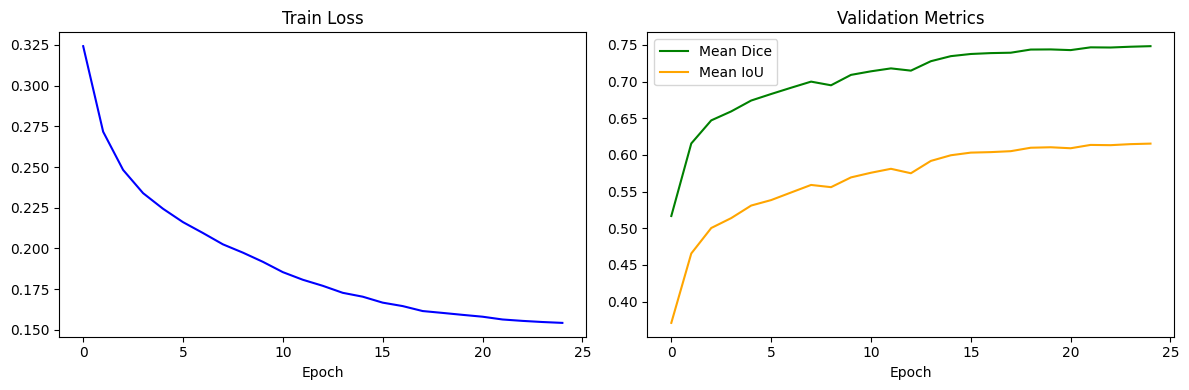

In [11]:
print("\nGenerating Analysis Report and Prediction Masks...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history['train_loss'], color='blue')
ax1.set_title('Train Loss')
ax1.set_xlabel('Epoch')

ax2.plot(history['val_dice'], label='Mean Dice', color='green')
ax2.plot(history['val_iou'], label='Mean IoU', color='orange')
ax2.set_title('Validation Metrics')
ax2.set_xlabel('Epoch')
ax2.legend()
plt.tight_layout()
plt.savefig(BASE_DIR / 'training_curves.png', dpi=120)
plt.show()

In [16]:
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()
print(f'Using threshold: {best_model_thr:.2f} (best validation)')

meta = {'best_val_score': best_val_score, 'best_thr': best_model_thr}
with open(BASE_DIR / 'meta.json', 'w') as f:
    json.dump(meta, f, indent=2)
total_time = 0.0

@torch.no_grad()
def predict_one(image_path, prompt):
    img = Image.open(image_path).convert('RGB')
    W, H = img.size
    enc = processor(
        text=[prompt],
        images=[img],
        return_tensors='pt',
        padding='max_length',
        truncation=True,
        max_length=77
    )
    enc = {k: v.to(DEVICE) for k, v in enc.items()}
    with autocast(enabled=USE_FP16):
        outputs = model(
            pixel_values=enc['pixel_values'],
            input_ids=enc['input_ids'],
            attention_mask=enc['attention_mask']
        )
        logits = outputs.logits
    prob = torch.sigmoid(logits.float())

    if prob.dim() == 4:
        prob = prob.squeeze(1)
    prob = prob[0].unsqueeze(0).unsqueeze(0)  
    prob = F.interpolate(prob, size=(H, W), mode='bilinear', align_corners=False)
    prob = prob[0, 0].cpu().numpy()

    return (prob > best_model_thr).astype(np.uint8) * 255

for item in tqdm(test_items, desc='Inference'):
    t0 = time.time()
    prompt = "segment taping area" if item['task_type'] == "taping" else "segment crack"
    mask = predict_one(item['image_path'], prompt)
    total_time += time.time() - t0
    slug = prompt.replace(' ', '_')
    Image.fromarray(mask, 'L').save(PRED_DIR / f"{item['image_id']}__{slug}.png")

print(f'Saved {len(test_items)} masks to {PRED_DIR}')
print(f'Avg inference: {total_time/len(test_items)*1000:.1f} ms/image')

Using threshold: 0.80 (best validation)


Inference:   0%|          | 0/906 [00:00<?, ?it/s]

Saved 906 masks to /kaggle/working/working/predictions
Avg inference: 38.6 ms/image


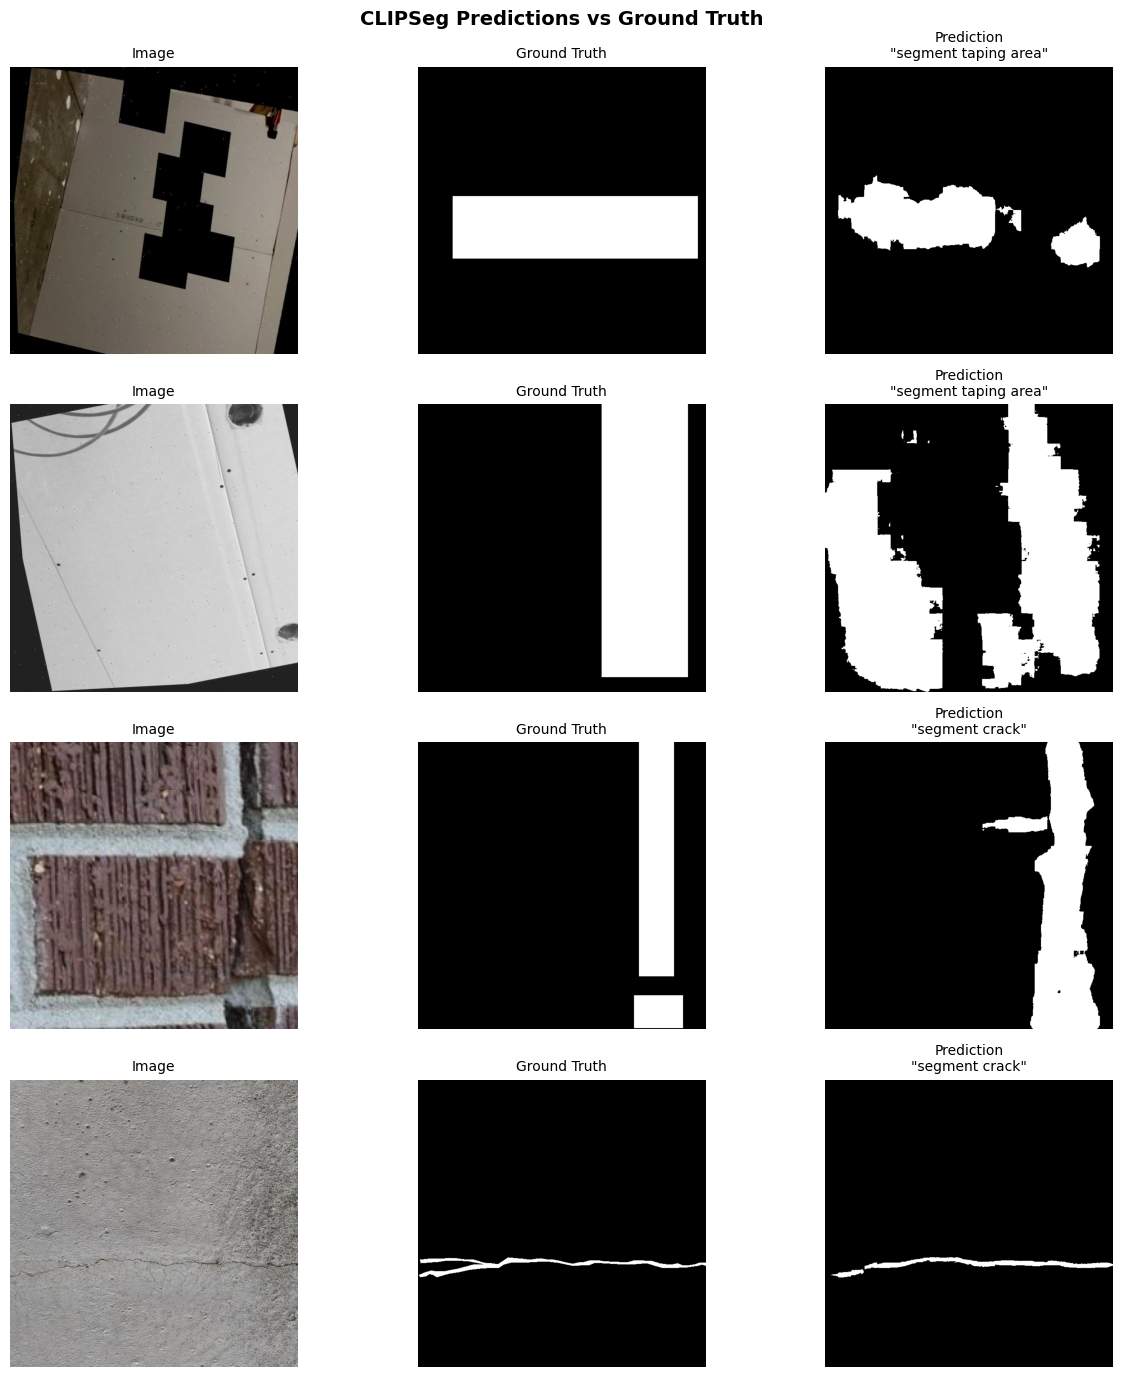

Saved visual_examples.png


In [17]:
n_show = 4
sample_taping = random.sample([it for it in test_items if it['task_type'] == 'taping'], 2)
sample_crack  = random.sample([it for it in test_items if it['task_type'] == 'crack'], 2)
samples = sample_taping + sample_crack

fig, axes = plt.subplots(n_show, 3, figsize=(13, n_show * 3.5))
for ax_row, item in zip(axes, samples):
    image = Image.open(item['image_path']).convert('RGB')
    gt_mask = item['orig_mask'] * 255 
    
    prompt = "segment taping area" if item['task_type'] == "taping" else "segment crack"
    slug = prompt.replace(' ', '_')
    pred_mask = np.array(Image.open(PRED_DIR / f"{item['image_id']}__{slug}.png"))
    
    ax_row[0].imshow(image);              ax_row[0].set_title('Image', fontsize=10)
    ax_row[1].imshow(gt_mask, cmap='gray'); ax_row[1].set_title('Ground Truth', fontsize=10)
    ax_row[2].imshow(pred_mask, cmap='gray'); ax_row[2].set_title(f'Prediction\n"{prompt}"', fontsize=10)
    for ax in ax_row: ax.axis('off')

plt.suptitle('CLIPSeg Predictions vs Ground Truth', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE_DIR / 'visual_examples.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved visual_examples.png')


In [19]:
ckpt_mb = os.path.getsize(CKPT_PATH) / 1e6
total_p = sum(p.numel() for p in model.parameters()) / 1e6
frozen_p = sum(p.numel() for p in model.parameters() if not p.requires_grad) / 1e6

print("\n" + "="*40)
print("             MODEL REPORT")
print("="*40)
print(f'Checkpoint Size: {ckpt_mb:.1f} MB')
print(f'Total Params   : {total_p:.1f}M')
print(f'Frozen Params  : {frozen_p:.1f}M (Text Encoder)')
print(f'Trainable Prms : {total_p - frozen_p:.1f}M (Vision + Decoder)')
print(f'Best Threshold : {best_model_thr:.2f}')
print(f'Best Val Score : {best_val_score:.4f} (Avg of mIoU & Dice)')
print(f'Avg Infer Time : {total_time/len(test_items)*1000:.1f} ms/image')
print("="*40)


             MODEL REPORT
Checkpoint Size: 603.2 MB
Total Params   : 150.7M
Frozen Params  : 63.2M (Text Encoder)
Trainable Prms : 87.6M (Vision + Decoder)
Best Threshold : 0.80
Best Val Score : 0.6818 (Avg of mIoU & Dice)
Avg Infer Time : 38.6 ms/image
